# Healthcare Diabetes Prediction

## Work With Data

### Loading Dataset

Libraries I'm going to use

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Import the data

In [125]:
data = pd.read_csv("Healthcare-Diabetes.csv")

Dropped the Id because idk if I need it, but I'm pretty sure it doesn't influence anything

In [126]:
data = data.drop(['Id'], axis=1)

Here's the data I have (2767 elements)

In [127]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
2763,2,75,64,24,55,29.7,0.370,33,0
2764,8,179,72,42,130,32.7,0.719,36,1
2765,6,85,78,0,0,31.2,0.382,42,0
2766,0,129,110,46,130,67.1,0.319,26,1


The data is clear (no missing values)

In [128]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2768 entries, 0 to 2767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2768 non-null   int64  
 1   Glucose                   2768 non-null   int64  
 2   BloodPressure             2768 non-null   int64  
 3   SkinThickness             2768 non-null   int64  
 4   Insulin                   2768 non-null   int64  
 5   BMI                       2768 non-null   float64
 6   DiabetesPedigreeFunction  2768 non-null   float64
 7   Age                       2768 non-null   int64  
 8   Outcome                   2768 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 194.8 KB


In [129]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Correlation between the data <br>
Because we have a Diabetes prediction, 'Glucose' really influences the Outcome

<Axes: >

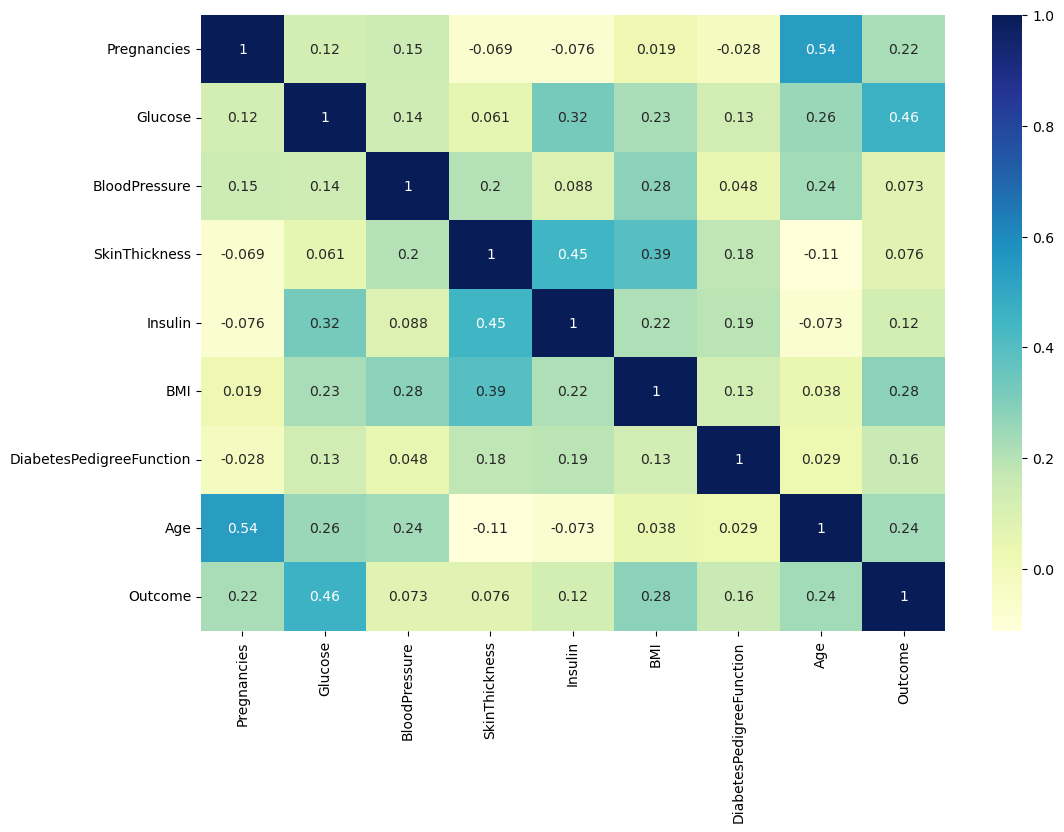

In [130]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='YlGnBu')

### Data Preprocessing

Split the data into two variables <br>
X is going to be the data which the model has to train to and y the outcome<br>
In this case the Outcome is either 1 or 0.

In [131]:
from sklearn.model_selection import train_test_split

X = data.drop(['Outcome'], axis=1)
y = data['Outcome']

In [132]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Models

Here is the model creation section, where I initiated each model <br>
In total I have 8 models (chose which I knew and thought are worth testing)<br>
Only 2 models have grid, those being Logistic Regression and Random Forest

### Logistic Regression

In [133]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [134]:
logistic_model.score(X_test, y_test)

0.7870036101083032

In [135]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, make_scorer

param_grid= {'class_weight': [{0:1, 1:v} for v in range(1,4)]}

grid_logistic = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    scoring={'precision': make_scorer(precision_score), 'recall_score': make_scorer(recall_score)},
    refit='precision',
    return_train_score= True,
    n_jobs=-1,
    cv=5
)

grid_logistic.fit(X_train, y_train)

,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 2}, ...]}"
,scoring,"{'precision': make_scorer(p...hod='predict'), 'recall_score': make_scorer(r...hod='predict')}"
,n_jobs,-1
,refit,'precision'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,penalty,'l2'


In [136]:
pd.DataFrame(grid_logistic.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,params,split0_test_precision,split1_test_precision,split2_test_precision,split3_test_precision,...,mean_test_recall_score,std_test_recall_score,rank_test_recall_score,split0_train_recall_score,split1_train_recall_score,split2_train_recall_score,split3_train_recall_score,split4_train_recall_score,mean_train_recall_score,std_train_recall_score
0,0.016874,0.002516,0.005516,0.000251,"{0: 1, 1: 1}","{'class_weight': {0: 1, 1: 1}}",0.752137,0.762295,0.646018,0.688406,...,0.565266,0.050952,3,0.568627,0.554649,0.585644,0.566069,0.556281,0.566254,0.011098
1,0.026533,0.006690,0.004374,0.001025,"{0: 1, 1: 2}","{'class_weight': {0: 1, 1: 2}}",0.631285,0.675824,0.617647,0.596939,...,0.745446,0.038666,2,0.741830,0.737357,0.756933,0.747145,0.748777,0.746408,0.006630
2,0.022173,0.003178,0.003804,0.000815,"{0: 1, 1: 3}","{'class_weight': {0: 1, 1: 3}}",0.564444,0.573222,0.572770,0.566524,...,0.840752,0.034376,1,0.849673,0.840131,0.833605,0.851550,0.840131,0.843018,0.006669


In [137]:
grid_logistic.score(X_test, y_test)

0.7236842105263158

### Random Forest

In [138]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier()

forest_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [139]:
forest_model.score(X_test, y_test)

0.9927797833935018

In [140]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, make_scorer

param_grid = {
    "n_estimators": [100, 200, 500],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10]
}

grid_forest = GridSearchCV(forest_model, param_grid=param_grid,
                    scoring={'precision': make_scorer(precision_score), 'recall_score': make_scorer(recall_score)},
                    return_train_score=True,
                    refit='precision',
                    n_jobs=-1,
                    cv=5)

grid_forest.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,"{'precision': make_scorer(p...hod='predict'), 'recall_score': make_scorer(r...hod='predict')}"
,n_jobs,-1
,refit,'precision'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,100


In [141]:

grid_forest.score(X_test, y_test)

0.9945652173913043

In [142]:
grid_forest.best_params_

{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}

### XGBoost

In [143]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier()

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [144]:
xgb_model.score(X_test, y_test)

0.9927797833935018

### SVM

In [145]:
from sklearn.svm import SVC

svc_model = SVC()

svc_model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [146]:
svc_model.score(X_test, y_test)

0.7725631768953068

### KNeighborsRegressor

In [147]:
from sklearn.neighbors import KNeighborsClassifier

neighbor_model = KNeighborsClassifier()

neighbor_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [148]:
neighbor_model.score(X_test, y_test)

0.8267148014440433

### Gradient Booster Classifier

In [149]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()

gb_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [150]:
gb_model.score(X_test, y_test)

0.8592057761732852

## Models' summary

Takes each model and tests it's precision, accuracy, recall and F1(precision and recall together)

In [151]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

models = {
    "LogisticRegression" : logistic_model,
    "LogisticRegressionGrid": grid_logistic,
    "RandomForestClassifier": forest_model,
    "RandomForestClassifierGrid": grid_forest,
    "XGBClassifier": xgb_model,
    "SVM": svc_model,
    "KNeighborsClassifier": neighbor_model,
    "GradientBoostingClassifier": gb_model
}

for name, model in models.items():

    #model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1})


Here are the results <br>
Arranged from the best to worst

In [152]:
results_df_sorted = pd.DataFrame(results).sort_values(
    by="F1 Score", ascending=False).reset_index(drop=True)
results_df_sorted.index = range(1, len(results)+1)
pd.DataFrame(results_df_sorted)

,Model,Accuracy,Precision,Recall,F1 Score
1,RandomForestClassifier,0.992780,0.994565,0.983871,0.989189
2,RandomForestClassifierGrid,0.992780,0.994565,0.983871,0.989189
3,XGBClassifier,0.992780,0.994565,0.983871,0.989189
4,GradientBoostingClassifier,0.859206,0.784211,0.801075,0.792553
5,KNeighborsClassifier,0.826715,0.714286,0.806452,0.757576
6,LogisticRegression,0.787004,0.723684,0.591398,0.650888
7,LogisticRegressionGrid,0.787004,0.723684,0.591398,0.650888
8,SVM,0.772563,0.714286,0.537634,0.613497


Through 2767 elements, only 952 are marked as 1 at Outcome

In [153]:
data['Outcome'].sum()

np.int64(952)

## Conclusion

Several machine learning models were tested to predict diabetes using the dataset. The models were evaluated using accuracy, precision, recall, and F1 score. <br>

The results show that Random Forest and XGBoost performed the best, with an accuracy of about 0.99 and an F1 score of about 0.99. This means that these models were very effective at correctly identifying both cases. <br>
Tuning the Random Forest with GridSearch didn't really change the results, which suggests the default parameters were almost suitable.<br>

Gradient Boosting and K-Nearest Neighbors achieved medium performance, while Logistic Regression and SVM had the lowest scores among the tested models.<br>

Overall, the results indicate that tree-based models, especially Random Forest and XGBoost, work best for this dataset.(The main reason is because it's a classification problem)